# Step 3 Data Preprocessing, Applied EDA & Feature Engineering

## Data Preprocessing: Handling Duplicates

### Subtask:
Check for and handle duplicate rows in the dataset.

In [ ]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()

print(f"Number of duplicate rows found: {duplicate_rows}")

if duplicate_rows > 0:
    print("Handling duplicate rows by removing them.")
    df.drop_duplicates(inplace=True)
    print(f"Number of rows after removing duplicates: {len(df)}")
else:
    print("No duplicate rows found. The dataset is already free of duplicates.")

Number of duplicate rows found: 298
Handling duplicate rows by removing them.
Number of rows after removing duplicates: 32002


## Data Preprocessing: Handling Missing Values (Imputation)

### Subtask:
Impute missing values based on the decided strategy: median for numerical features and mode for discrete numerical/pseudo-categorical features.

In [ ]:
# Define numerical and discrete numerical/pseudo-categorical columns for imputation
numerical_cols_for_median = [
    'age',
    'transaction_amount',
    'account_balance',
    'merchant_distance_km',
    'merchant_risk_score'
]

discrete_cols_for_mode = [
    'num_transactions_today',
    'transaction_hour',
    'is_foreign_transaction',
    'prev_fraud_flag'
]

print("Imputing missing values...")

# Impute numerical columns with their median
for col in numerical_cols_for_median:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"- Imputed missing values in '{col}' with median: {median_val}")

# Impute discrete numerical/pseudo-categorical columns with their mode
for col in discrete_cols_for_mode:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0] # .mode() can return multiple values, take the first
        df[col].fillna(mode_val, inplace=True)
        print(f"- Imputed missing values in '{col}' with mode: {mode_val}")

print("\nMissing values after imputation:")
print(df.isnull().sum())

Imputing missing values...
- Imputed missing values in 'age' with median: 46.0
- Imputed missing values in 'transaction_amount' with median: 7468.145
- Imputed missing values in 'account_balance' with median: 25056.3
- Imputed missing values in 'merchant_distance_km' with median: 2508.8
- Imputed missing values in 'merchant_risk_score' with median: 5.5
- Imputed missing values in 'num_transactions_today' with mode: 16.0
- Imputed missing values in 'transaction_hour' with mode: 4.0
- Imputed missing values in 'is_foreign_transaction' with mode: 0.0
- Imputed missing values in 'prev_fraud_flag' with mode: 0.0

Missing values after imputation:
age                       0
transaction_amount        0
account_balance           0
num_transactions_today    0
is_foreign_transaction    0
transaction_hour          0
prev_fraud_flag           0
merchant_distance_km      0
merchant_risk_score       0
is_fraud                  0
dtype: int64


/tmp/ipykernel_893/3759833093.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipykernel_893/3759833093.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

## Feature Engineering: Scaling Numerical Features

### Subtask:
Scale numerical features to bring them to a similar range. This is important for many machine learning algorithms that are sensitive to the scale of input features.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to be scaled
# Exclude binary flags and the target variable
columns_to_scale = [
    'age',
    'transaction_amount',
    'account_balance',
    'num_transactions_today',
    'merchant_distance_km',
    'merchant_risk_score'
]

print(f"Scaling the following numerical columns: {', '.join(columns_to_scale)}")

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected columns
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

print("\nNumerical features have been scaled. Displaying descriptive statistics of scaled features:")
print(df[columns_to_scale].describe())

Scaling the following numerical columns: age, transaction_amount, account_balance, num_transactions_today, merchant_distance_km, merchant_risk_score

Numerical features have been scaled. Displaying descriptive statistics of scaled features:
                age  transaction_amount  account_balance  \
count  3.200200e+04        3.200200e+04     3.200200e+04   
mean  -9.636134e-17        1.731840e-17     2.540587e-16   
std    1.000016e+00        1.000016e+00     1.000016e+00   
min   -1.722687e+00       -1.744990e+00    -1.755488e+00   
25%   -8.627981e-01       -8.560610e-01    -8.595882e-01   
50%   -2.909619e-03       -4.135436e-04     1.324482e-03   
75%    8.569788e-01        8.556481e-01     8.602928e-01   
max    1.716867e+00        1.759230e+00     1.750181e+00   

       num_transactions_today  merchant_distance_km  merchant_risk_score  
count            3.200200e+04          3.200200e+04         3.200200e+04  
mean             6.216860e-17          2.975212e-16        -2.837553

## Feature Engineering: Domain-Derived Features

### Subtask:
Create new features from existing ones based on domain knowledge to potentially improve model performance. A key new feature will be the `transaction_to_balance_ratio`.

In [ ]:
# Create a new feature: transaction_to_balance_ratio
# Add a small epsilon to the denominator to avoid division by zero if account_balance is 0
epsilon = 1e-6
df['transaction_to_balance_ratio'] = df['transaction_amount'] / (df['account_balance'] + epsilon)

print("New feature 'transaction_to_balance_ratio' created. Displaying its descriptive statistics:")
print(df['transaction_to_balance_ratio'].describe())

# It might be beneficial to scale this new feature as well, given the others are scaled
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler for the new feature
scaler_new = StandardScaler()

# Scale the new feature
df['transaction_to_balance_ratio'] = scaler_new.fit_transform(df[['transaction_to_balance_ratio']])

print("\n'transaction_to_balance_ratio' after scaling:")
print(df['transaction_to_balance_ratio'].describe())

New feature 'transaction_to_balance_ratio' created. Displaying its descriptive statistics:
count    32002.000000
mean         0.517578
std        192.253386
min      -2140.374507
25%         -1.015369
50%         -0.000446
75%          0.984849
max      22796.958455
Name: transaction_to_balance_ratio, dtype: float64

'transaction_to_balance_ratio' after scaling:
count    3.200200e+04
mean    -1.110154e-18
std      1.000016e+00
min     -1.113596e+01
25%     -7.973698e-03
50%     -2.694527e-03
75%      2.430532e-03
max      1.185768e+02
Name: transaction_to_balance_ratio, dtype: float64


## Applied EDA: Feature Relationships (Correlation Analysis)

### Subtask:
Analyze the relationships between numerical features using a correlation matrix and visualize it with a heatmap. This helps in understanding feature dependencies and potential multicollinearity.

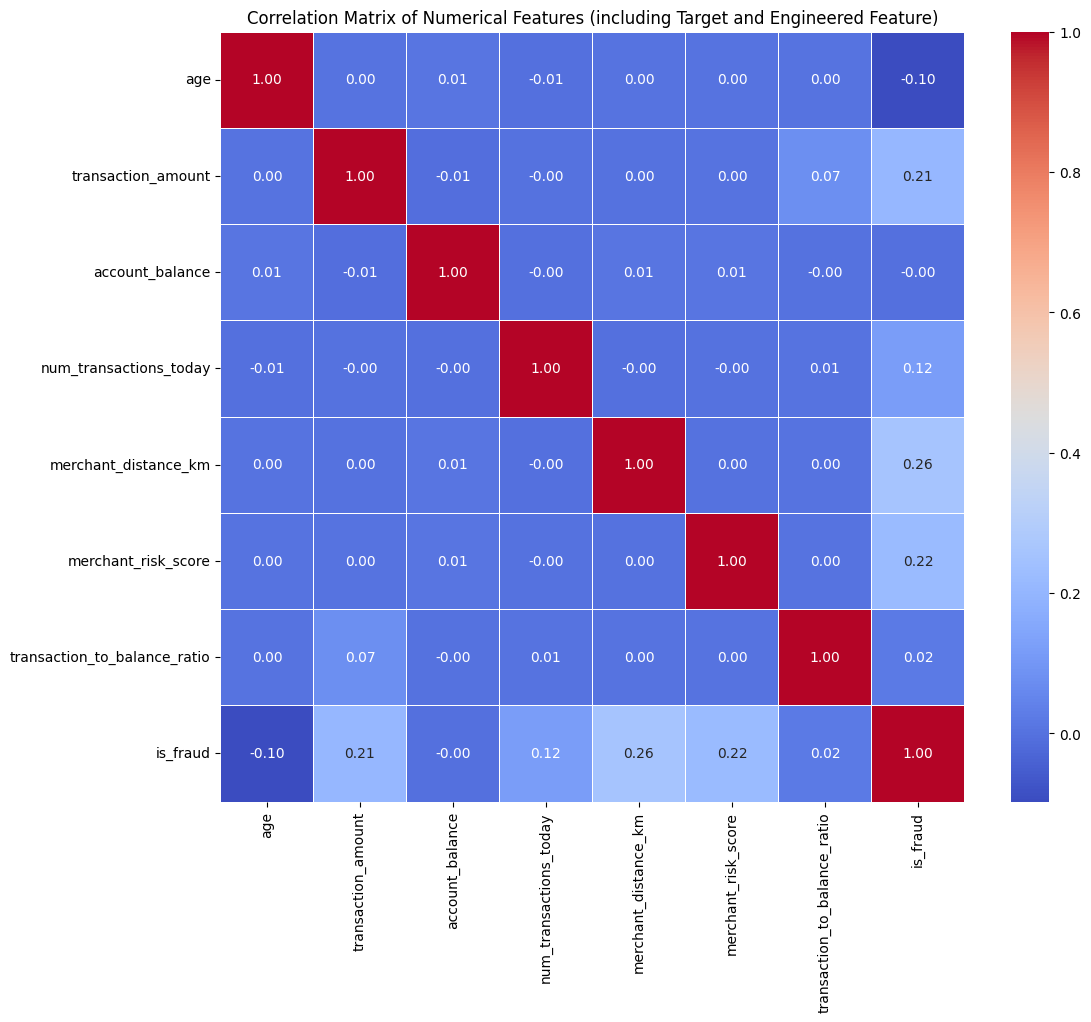


Correlation Matrix (Numerical Features):
                                   age  transaction_amount  account_balance  \
age                           1.000000            0.003194     6.118330e-03   
transaction_amount            0.003194            1.000000    -1.038533e-02   
account_balance               0.006118           -0.010385     1.000000e+00   
num_transactions_today       -0.005613           -0.001537    -4.723313e-03   
merchant_distance_km          0.001921            0.000395     8.150062e-03   
merchant_risk_score           0.004295            0.002161     6.212547e-03   
transaction_to_balance_ratio  0.003139            0.074595    -2.692208e-09   
is_fraud                     -0.097120            0.205602    -4.835503e-03   

                              num_transactions_today  merchant_distance_km  \
age                                        -0.005613              0.001921   
transaction_amount                         -0.001537              0.000395   
account_bala

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Include the newly engineered feature in the list for correlation analysis
features_for_correlation = [
    'age',
    'transaction_amount',
    'account_balance',
    'num_transactions_today',
    'merchant_distance_km',
    'merchant_risk_score',
    'transaction_to_balance_ratio',
    'is_fraud' # Include target variable to see its correlation with features
]

# Calculate the correlation matrix
correlation_matrix = df[features_for_correlation].corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features (including Target and Engineered Feature)')
plt.show()

print("\nCorrelation Matrix (Numerical Features):")
print(correlation_matrix)

In [ ]:
# Random Forest Feature Importance

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define features and target
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Initialize Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train the Random Forest model
rf_model.fit(X_train, y_train)

# Calculate feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display feature importance
print("Random Forest Feature Importance:")
display(feature_importance)

Random Forest Feature Importance:


,Feature,Importance
7,merchant_distance_km,0.166855
1,transaction_amount,0.138635
8,merchant_risk_score,0.128916
9,transaction_to_balance_ratio,0.096304
2,account_balance,0.093292
3,num_transactions_today,0.090489
0,age,0.088783
5,transaction_hour,0.072230
6,prev_fraud_flag,0.067561
4,is_foreign_transaction,0.056935


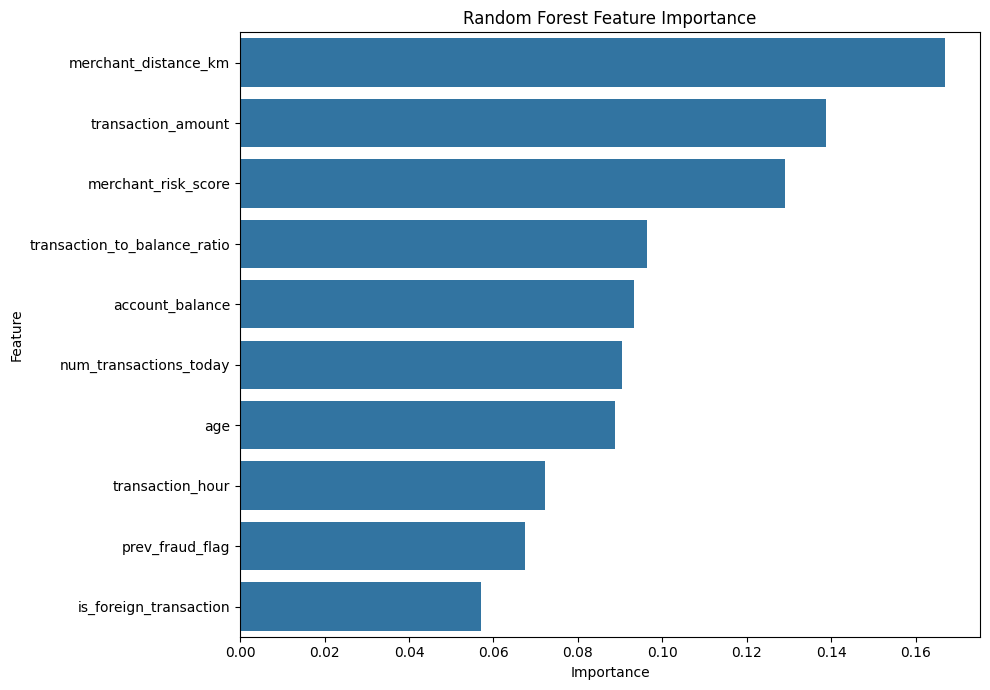

In [ ]:
# Plot Random Forest Feature Importance

plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
# Select features based on Random Forest importance

importance_threshold = 0.05

selected_features = feature_importance[
    feature_importance['Importance'] >= importance_threshold
]['Feature'].tolist()

print("Selected Features:")
print(selected_features)

Selected Features:
['merchant_distance_km', 'transaction_amount', 'merchant_risk_score', 'transaction_to_balance_ratio', 'account_balance', 'num_transactions_today', 'age', 'transaction_hour', 'prev_fraud_flag', 'is_foreign_transaction']


# PCA

In [ ]:
from sklearn.decomposition import PCA

# Exclude target
X = df.drop(columns=['is_fraud'])

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X)

# Explained variance
explained_variance = pca.explained_variance_ratio_

pca_results = pd.DataFrame({
    'Principal Component': range(1, len(explained_variance) + 1),
    'Explained Variance Ratio': explained_variance,
    'Cumulative Explained Variance': explained_variance.cumsum()
})

display(pca_results)

,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,1,0.869708,0.869708
1,2,0.019481,0.889189
2,3,0.018432,0.907621
3,4,0.018119,0.925741
4,5,0.018090,0.943831
5,6,0.017987,0.961818
6,7,0.017904,0.979722
7,8,0.016737,0.996460
8,9,0.002217,0.998677
9,10,0.001323,1.000000


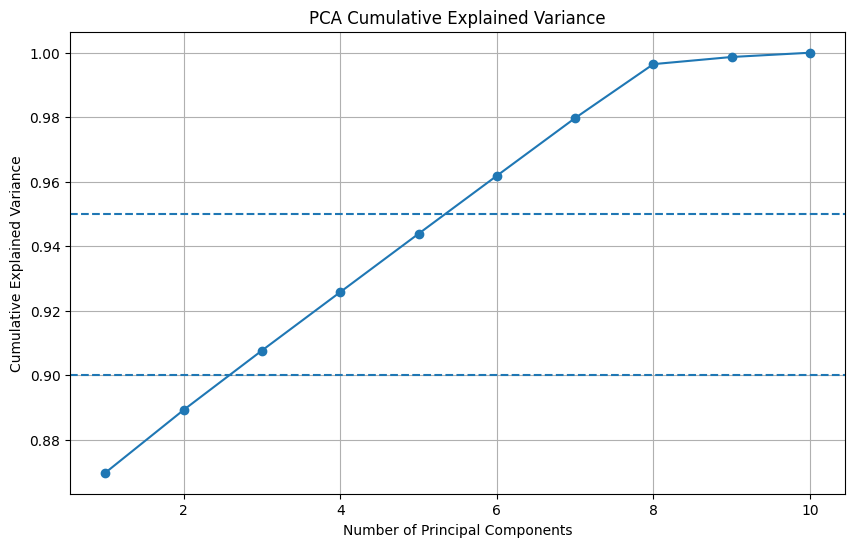

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance.cumsum(),
    marker='o'
)

plt.axhline(y=0.90, linestyle='--')
plt.axhline(y=0.95, linestyle='--')

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.grid(True)
plt.show()